Comparison of the Antarctic Slope Current (ASC) across three simulations: **SO6** (BSOSE iteration 168, physics-only, 1/6°, 2013–2021), **BGOSE6** (BSOSE iteration 41, with biogeochemistry/meltwater, 1/6°, 2013–2021), and **SoHi** (high-resolution MITgcm, 1/24°, 2007). All data from `/data/globus/zkaufman`. Longitudes follow the −180 to 180° convention throughout.

Figures produced (in order):

1. **SOSE_ASC_isobath_circumpolar.png** — Circumpolar flat map of time-mean, depth-averaged (0–1200 m) along-slope velocity scattered along the 1000 m isobath for each simulation. Gold box marks the Amundsen–Bellingshausen Sea (ASE) focus region.

2. **SOSE_compare_maps_ASE_bathy.png** — ASE bathymetry maps (SouthPolarStereo) for each simulation, with the 1000 m isobath overlaid in yellow.

3. **SOSE_ASC_isobath_section.png** — Depth–longitude contourf (0–1000 m) of time-mean along-slope velocity along the 1000 m isobath, restricted to the ASE region.

4. **SOSE_ASC_isobath_seasonal.png** — Monthly climatology of ASC velocity averaged over the ASE isobath segment, shown as depth–month contourf (0–1000 m).

5. **SOSE_ASC_summary.png** — Summary scatter: time-and-space-mean ASC velocity vs. nominal model resolution. Errorbars show interannual std (SO6 and BGOSE6 only). Marker shape distinguishes meltwater (○) from no-meltwater (×) configurations.

6. **SOSE_transect_sections.png** — Cross-slope (latitude × depth) sections of time-mean along-slope velocity at 115°W for each simulation.

In [1]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from glob import glob
%matplotlib inline

data_dir = '/data/globus/zkaufman'
t_tag    = '201301to202112'

# Spin up a local dask cluster — needed for the large SoHi daily fields.
# Teardown guard: re-running this cell closes any existing cluster cleanly.
from dask.distributed import Client, LocalCluster, wait

try:
    client.close()
    cluster.close()
    print('Previous cluster closed.')
except NameError:
    pass

cluster = LocalCluster()
client  = Client(cluster)
print(client)
print('Dashboard:', client.dashboard_link)


<Client: 'tcp://127.0.0.1:33437' processes=16 threads=128, memory=0.98 TiB>
Dashboard: http://127.0.0.1:8787/status


In [3]:
bathym_so6   = xr.open_dataset(os.path.join(data_dir, 'bathym_SO6.nc'))['bathymetry']
bathym_bgose = xr.open_dataset(os.path.join(data_dir, 'bathym_BGOSE6.nc'))['bathymetry']
bathym_sohi  = xr.open_dataset(os.path.join(data_dir, 'bathym_on_uv.nc'))['bathymetry']

# Convert all lon coordinates from 0-360 to -180-180 throughout the notebook.
def _lon180(da, lon_dim='lon'):
    lon_new = np.where(da[lon_dim].values > 180, da[lon_dim].values - 360, da[lon_dim].values)
    return da.assign_coords({lon_dim: lon_new}).sortby(lon_dim)

bathym_so6   = _lon180(bathym_so6)
bathym_bgose = _lon180(bathym_bgose)
bathym_sohi  = _lon180(bathym_sohi)

u_3d_so6   = _lon180(xr.open_zarr(os.path.join(data_dir, f'u_along_0_1200m_SO6_{t_tag}_monthly.zarr'))['u_along'])
u_3d_bgose = _lon180(xr.open_zarr(os.path.join(data_dir, f'u_along_0_1200m_BGOSE6_{t_tag}_monthly.zarr'))['u_along'])

#depth_100_so6   = float(u_3d_so6.depth.sel(depth=-100.0, method='nearest'))
#depth_100_bgose = float(u_3d_bgose.depth.sel(depth=-100.0, method='nearest'))
#depth_500_so6   = float(u_3d_so6.depth.sel(depth=-500.0, method='nearest'))
#depth_500_bgose = float(u_3d_bgose.depth.sel(depth=-500.0, method='nearest'))

#print(f'SO6   ~100m: {depth_100_so6:.1f} m    ~500m: {depth_500_so6:.1f} m')
#print(f'BGOSE ~100m: {depth_100_bgose:.1f} m    ~500m: {depth_500_bgose:.1f} m')

#u_100m_so6   = u_3d_so6.sel(depth=depth_100_so6)
#u_100m_bgose = u_3d_bgose.sel(depth=depth_100_bgose)
#u_500m_so6   = u_3d_so6.sel(depth=depth_500_so6)
#u_500m_bgose = u_3d_bgose.sel(depth=depth_500_bgose)

# SoHi: 4 quarterly daily zarr stores (2007), native chunks (1, 20, 256, 256).
sohi_paths = sorted(glob(os.path.join(data_dir, 'u_along_fulldepth_*_daily.zarr')))
u_3d_sohi = xr.concat(
    [xr.open_zarr(p, consolidated=False, chunks={'date': 1}) for p in sohi_paths],
    dim='date', data_vars='minimal', coords='minimal', compat='equals'
)['u_along'].sortby('date')

# Restrict SoHi to 0–1200 m before any large compute, then convert lon convention.
n_depth_sohi = int(np.sum(u_3d_sohi.depth.values >= -1200.0))
u_3d_sohi    = u_3d_sohi.isel(depth=slice(None, n_depth_sohi))
u_3d_sohi    = _lon180(u_3d_sohi)

#depth_100_sohi = float(u_3d_sohi.depth.sel(depth=-100.0, method='nearest'))
#depth_500_sohi = float(u_3d_sohi.depth.sel(depth=-500.0, method='nearest'))
#print(f'SoHi  ~100m: {depth_100_sohi:.1f} m    ~500m: {depth_500_sohi:.1f} m')

#u_100m_sohi = u_3d_sohi.sel(depth=depth_100_sohi)
#u_500m_sohi = u_3d_sohi.sel(depth=depth_500_sohi)

In [4]:
lon_min, lon_max = -120.0, -70.0   # ASE domain in -180-180 convention (was 240-290°E)
lat_min, lat_max = -76.0, -67.0

def subset(da):
    return da.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))

bathy_so6_km   = subset(bathym_so6).where(subset(bathym_so6)   > 0) / 1000.0
bathy_bgose_km = subset(bathym_bgose).where(subset(bathym_bgose) > 0) / 1000.0
bathy_sohi_km  = subset(bathym_sohi).where(subset(bathym_sohi)  > 0) / 1000.0
bathy_so6_m    = subset(bathym_so6).where(subset(bathym_so6)   > 0)
bathy_bgose_m  = subset(bathym_bgose).where(subset(bathym_bgose) > 0)
bathy_sohi_m   = subset(bathym_sohi).where(subset(bathym_sohi)  > 0)

#u_100m_so6_mean   = subset(u_100m_so6).mean('time').compute()
#u_100m_bgose_mean = subset(u_100m_bgose).mean('time').compute()
#u_100m_sohi_mean  = subset(u_100m_sohi).mean('date').compute()
#u_500m_so6_mean   = subset(u_500m_so6).mean('time').compute()
#u_500m_bgose_mean = subset(u_500m_bgose).mean('time').compute()
#u_500m_sohi_mean  = subset(u_500m_sohi).mean('date').compute()

#u_100m_so6_mean   = u_100m_so6_mean.where(bathy_so6_m   > 0)
#u_100m_bgose_mean = u_100m_bgose_mean.where(bathy_bgose_m > 0)
#u_100m_sohi_mean  = u_100m_sohi_mean.where(bathy_sohi_m  > 0)
#u_500m_so6_mean   = u_500m_so6_mean.where(bathy_so6_m   > 0)
#u_500m_bgose_mean = u_500m_bgose_mean.where(bathy_bgose_m > 0)
#u_500m_sohi_mean  = u_500m_sohi_mean.where(bathy_sohi_m  > 0)

#print('Subsets ready.')
#print(f'  SO6   bathy {bathy_so6_km.shape}  u_100m {u_100m_so6_mean.shape}')
#print(f'  BGOSE bathy {bathy_bgose_km.shape}  u_100m {u_100m_bgose_mean.shape}')
#print(f'  SoHi  bathy {bathy_sohi_km.shape}  u_100m {u_100m_sohi_mean.shape}')

In [5]:
def iso_contour(da, level, figsize=(6, 3), imshow=True):
    """
    Return the longest contour line (x,y) for a single contour level.
    Works with xarray's .plot.contour across Matplotlib/xarray versions.
    """
    if imshow:
        fig, ax = plt.subplots(ncols=2, figsize=figsize)
        ax0, ax1 = ax
    else:
        fig, ax0 = plt.subplots(ncols=1, figsize=figsize)
        ax1 = None

    cs = da.plot.contour(ax=ax0, levels=[level], add_colorbar=False)
    ax0.set_title(f"All Contours @ {level}")

    seglists = cs.allsegs
    if not seglists or not seglists[0]:
        plt.close(fig)
        raise ValueError(f"No contour segments found at level {level}.")

    longest = max(seglists[0], key=lambda seg: seg.shape[0])
    xaxis_coords, yaxis_coords = longest[:, 0], longest[:, 1]

    if ax1 is not None:
        ax1.plot(xaxis_coords, yaxis_coords, 'r-', lw=1.5)
        ax1.set_title("Isolated Longest Contour")

    if not imshow:
        plt.close(fig)

    return xaxis_coords, yaxis_coords

# Precompute 1000m isobath for each simulation (suppresses diagnostic figures)
iso_x_so6,   iso_y_so6   = iso_contour(bathy_so6_m,   1000, imshow=False)
iso_x_bgose, iso_y_bgose = iso_contour(bathy_bgose_m, 1000, imshow=False)
iso_x_sohi,  iso_y_sohi  = iso_contour(bathy_sohi_m,  1000, imshow=False)
print('1000m isobath computed:')
print(f'  SO6   {iso_x_so6.shape}  BGOSE6 {iso_x_bgose.shape}  SoHi {iso_x_sohi.shape}')


1000m isobath computed:
  SO6   (419,)  BGOSE6 (385,)  SoHi (1613,)


In [6]:
# Load ASC velocity along the 1000m isobath.
# Zarrs from ASC_index_calculator_SO6_BGOSE6_SoHi.ipynb; dims: (time/date, depth, s).

asc_so6   = xr.open_zarr(os.path.join(data_dir, 'ASC_isobathfollow_0_1200m_SO6_201301to202112_monthly.zarr'))
asc_bgose = xr.open_zarr(os.path.join(data_dir, 'ASC_isobathfollow_0_1200m_BGOSE6_201301to202112_monthly.zarr'))
asc_sohi  = xr.open_zarr(os.path.join(data_dir, 'ASC_isobathfollow_0_1200m_SoHi_2007_daily.zarr'))

# Cell-thickness weights for the 0-1200m depth average.
def depth_weights(u_da):
    z = u_da.depth.values
    edges = np.empty(z.size + 1)
    edges[1:-1] = 0.5 * (z[:-1] + z[1:])
    edges[0]    = 0.0
    edges[-1]   = z[-1] - (edges[-2] - z[-1])
    top_clip = np.minimum(0.0,     edges[:-1])
    bot_clip = np.maximum(-1200.0, edges[1:])
    thick    = np.maximum(0.0, top_clip - bot_clip)
    return xr.DataArray(thick, coords={'depth': u_da.depth}, dims=('depth',))

# Time-mean (keeping depth): shape (depth, s)
u_asc_so6_tmean   = asc_so6['u_along'].mean('time').compute()
u_asc_bgose_tmean = asc_bgose['u_along'].mean('time').compute()
u_asc_sohi_tmean  = asc_sohi['u_along'].mean('date').compute()

# Thickness-weighted depth + time mean: shape (s,)
w_so6   = depth_weights(asc_so6['u_along'])
w_bgose = depth_weights(asc_bgose['u_along'])
w_sohi  = depth_weights(asc_sohi['u_along'])

u_asc_so6   = asc_so6['u_along'].weighted(w_so6).mean('depth').mean('time').compute()
u_asc_bgose = asc_bgose['u_along'].weighted(w_bgose).mean('depth').mean('time').compute()
u_asc_sohi  = asc_sohi['u_along'].weighted(w_sohi).mean('depth').mean('date').compute()

# Convert isobath lon variables from 0-360 to -180-180 for notebook-wide consistency.
def _iso_lon180(arr): return np.where(arr > 180, arr - 360, arr)

lon_asc_so6   = _iso_lon180(asc_so6['lon'].values)
lon_asc_bgose = _iso_lon180(asc_bgose['lon'].values)
lon_asc_sohi  = _iso_lon180(asc_sohi['lon'].values)
lat_asc_so6   = asc_so6['lat'].values
lat_asc_bgose = asc_bgose['lat'].values
lat_asc_sohi  = asc_sohi['lat'].values

def ase_mask(lon, lat):
    return (lon >= lon_min) & (lon <= lon_max) & (lat >= lat_min) & (lat <= lat_max)

mask_so6   = ase_mask(lon_asc_so6,   lat_asc_so6)
mask_bgose = ase_mask(lon_asc_bgose, lat_asc_bgose)
mask_sohi  = ase_mask(lon_asc_sohi,  lat_asc_sohi)

vmax_asc = float(np.nanpercentile(np.abs(np.concatenate([
    u_asc_so6.values[mask_so6],
    u_asc_bgose.values[mask_bgose],
    u_asc_sohi.values[mask_sohi],
])), 99))
print(f'ASC isobath velocity colorbar: ±{vmax_asc:.4f} m/s')

ASC isobath velocity colorbar: ±0.1152 m/s


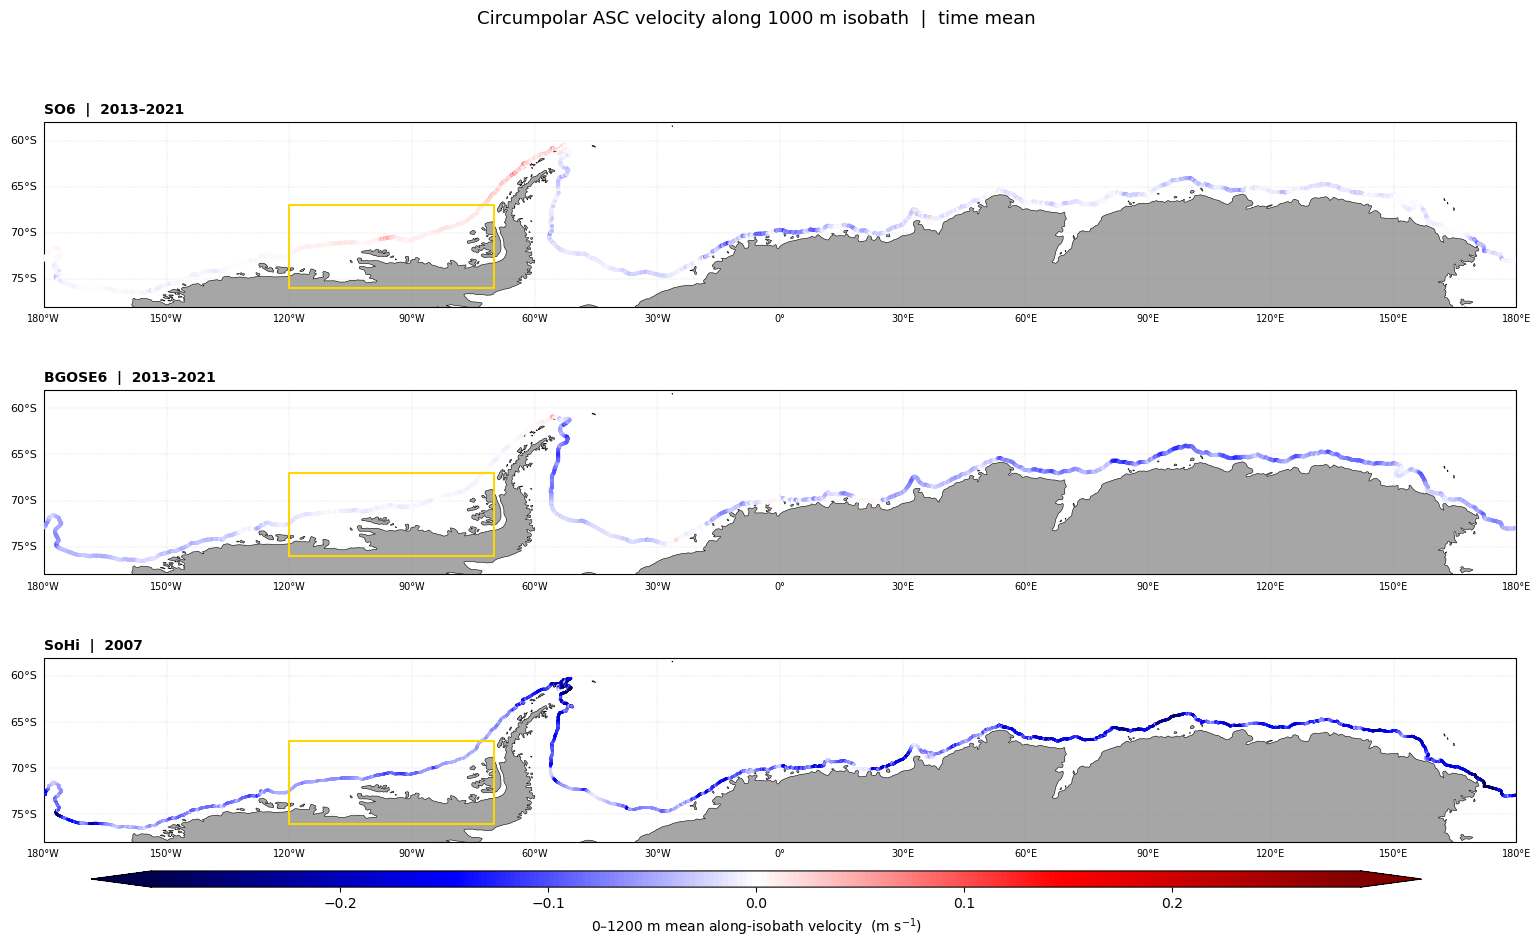

Saved SOSE_ASC_isobath_circumpolar.png


In [7]:
# Circumpolar ASC velocity along the 1000 m isobath — flat lat/lon strip
import matplotlib.colors as mcolors

proj_flat = ccrs.PlateCarree()
_pc = ccrs.PlateCarree()

vmax_circ = float(np.nanpercentile(np.abs(np.concatenate([
    u_asc_so6.values, u_asc_bgose.values, u_asc_sohi.values
])), 99))
norm_circ = mcolors.TwoSlopeNorm(vmin=-vmax_circ, vcenter=0, vmax=vmax_circ)
cmap_circ = plt.get_cmap('seismic')

# ASE domain box — dense edges to avoid straight-line artifacts
_n = 200
_b = np.vstack([
    np.c_[np.linspace(lon_min, lon_max, _n), np.full(_n, lat_min)],
    np.c_[np.full(_n, lon_max),              np.linspace(lat_min, lat_max, _n)],
    np.c_[np.linspace(lon_max, lon_min, _n), np.full(_n, lat_max)],
    np.c_[np.full(_n, lon_min),              np.linspace(lat_max, lat_min, _n)],
    [[lon_min, lat_min]],
])
ase_box_lon, ase_box_lat = _b[:, 0], _b[:, 1]

lat_all = np.concatenate([lat_asc_so6, lat_asc_bgose, lat_asc_sohi])
lat_lo  = np.floor(lat_all.min()) - 1
lat_hi  = np.ceil(lat_all.max())  + 2

titles_circ = ['SO6  |  2013–2021', 'BGOSE6  |  2013–2021', 'SoHi  |  2007']
lons_c  = [lon_asc_so6,   lon_asc_bgose,   lon_asc_sohi]
lats_c  = [lat_asc_so6,   lat_asc_bgose,   lat_asc_sohi]
u_c     = [u_asc_so6,     u_asc_bgose,     u_asc_sohi]
dsizes  = [8, 8, 4]

fig, axes = plt.subplots(3, 1, figsize=(19, 9),
                          subplot_kw={'projection': proj_flat},
                          gridspec_kw={'hspace': 0.45})

for ax, title, lons, lats, u_da, ds in zip(axes, titles_circ, lons_c, lats_c, u_c, dsizes):
    ax.set_extent([-180, 180, lat_lo, lat_hi], crs=_pc)
    ax.set_aspect('auto')
    ax.add_feature(cfeature.LAND, facecolor='0.65', zorder=2)
    ax.coastlines(color='k', linewidth=0.4, zorder=3)
    gl = ax.gridlines(crs=_pc, draw_labels=True,
                      linewidth=0.3, linestyle=':', color='gray', alpha=0.6, zorder=1)
    gl.xlocator     = mticker.FixedLocator(range(-180, 181, 30))
    gl.ylocator     = mticker.FixedLocator([-80, -75, -70, -65, -60, -55])
    gl.xformatter   = LONGITUDE_FORMATTER
    gl.yformatter   = LATITUDE_FORMATTER
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 7}
    gl.ylabel_style = {'size': 8}
    ax.scatter(lons, lats, c=u_da.values,
               cmap=cmap_circ, norm=norm_circ,
               s=ds, linewidths=0, edgecolors='none',
               transform=_pc, zorder=4)
    ax.plot(ase_box_lon, ase_box_lat,
            color='gold', linewidth=1.5, transform=_pc, zorder=5)
    ax.set_title(title, fontsize=10, fontweight='bold', loc='left')

fig.subplots_adjust(bottom=0.08)
cax_circ = fig.add_axes([0.15, 0.03, 0.70, 0.018])
sm = plt.cm.ScalarMappable(cmap=cmap_circ, norm=norm_circ)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax_circ, orientation='horizontal', extend='both')
cbar.set_label('0–1200 m mean along-isobath velocity  (m s$^{-1}$)', fontsize=10)

fig.suptitle('Circumpolar ASC velocity along 1000 m isobath  |  time mean',
             fontsize=13, y=1.005)

plt.savefig('SOSE_ASC_isobath_circumpolar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved SOSE_ASC_isobath_circumpolar.png')

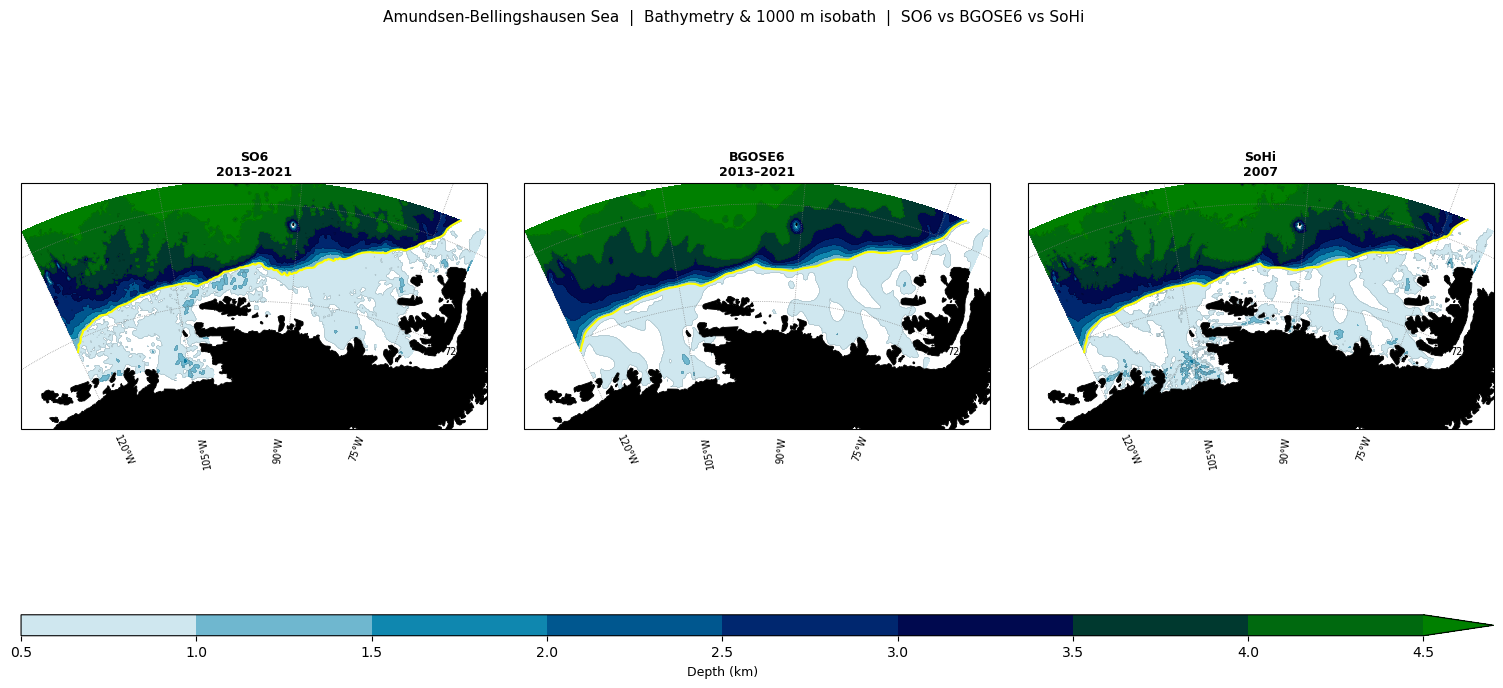

Saved SOSE_compare_maps_ASE_bathy.png


In [8]:
# Define here so this cell is self-contained (cell-04 redefines identically for the maps below)
proj = ccrs.SouthPolarStereo(central_longitude=265)
pc   = ccrs.PlateCarree()

def setup_ax(ax):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=pc)
    ax.add_feature(cfeature.LAND, facecolor='black', zorder=3)
    ax.coastlines(color='black', linewidth=0.6, zorder=4)
    gl = ax.gridlines(crs=pc, draw_labels=True,
                      linewidth=0.5, linestyle=':', color='gray', zorder=2)
    gl.xlocator      = mticker.FixedLocator([-120, -105, -90, -75])
    gl.ylocator      = mticker.FixedLocator([-76, -72, -68, -64, -60])
    gl.top_labels    = False
    gl.right_labels  = False
    gl.left_labels   = True
    gl.bottom_labels = True
    gl.xformatter    = LONGITUDE_FORMATTER
    gl.yformatter    = LATITUDE_FORMATTER
    gl.xlabel_style  = {'size': 7}
    gl.ylabel_style  = {'size': 7}

time_domains = {'SO6': '2013–2021', 'BGOSE6': '2013–2021', 'SoHi': '2007'}

bathy_levels = np.arange(0.5, 5.0, 0.5)

fig = plt.figure(figsize=(19, 7))
gs  = GridSpec(2, 3, figure=fig,
               height_ratios=[5, 0.25],
               hspace=0.45, wspace=0.08)

ax_so6   = fig.add_subplot(gs[0, 0], projection=proj)
ax_bgose = fig.add_subplot(gs[0, 1], projection=proj)
ax_sohi  = fig.add_subplot(gs[0, 2], projection=proj)
cax_bathy = fig.add_subplot(gs[1, :])

for ax, bk, iso_x, iso_y, sim in zip(
        [ax_so6,    ax_bgose,    ax_sohi],
        [bathy_so6_km,  bathy_bgose_km,  bathy_sohi_km],
        [iso_x_so6,     iso_x_bgose,     iso_x_sohi],
        [iso_y_so6,     iso_y_bgose,     iso_y_sohi],
        ['SO6', 'BGOSE6', 'SoHi']):
    setup_ax(ax)
    lon2d, lat2d = np.meshgrid(bk.lon, bk.lat)
    cf = ax.contourf(lon2d, lat2d, bk.values,
                     levels=bathy_levels, cmap='ocean_r',
                     extend='max', transform=pc, zorder=1)
    ax.contour(lon2d, lat2d, bk.values,
               levels=bathy_levels, colors='k',
               linewidths=0.2, alpha=0.4, transform=pc, zorder=2)
    ax.plot(iso_x, iso_y, color='yellow', linewidth=1.5, transform=pc, zorder=5)
    ax.set_title(f'{sim}\n{time_domains[sim]}', fontsize=9, fontweight='bold')

cb = fig.colorbar(cf, cax=cax_bathy, orientation='horizontal', extend='max')
cb.set_label('Depth (km)', fontsize=9)

fig.suptitle('Amundsen-Bellingshausen Sea  |  Bathymetry & 1000 m isobath  |  SO6 vs BGOSE6 vs SoHi',
             fontsize=11, y=1.005)

plt.savefig('SOSE_compare_maps_ASE_bathy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved SOSE_compare_maps_ASE_bathy.png')

In [9]:
# Subset tmean (depth, s) to ASE isobath points and 0–1000 m depth.
s_so6   = np.where(mask_so6)[0]
s_bgose = np.where(mask_bgose)[0]
s_sohi  = np.where(mask_sohi)[0]

def ase_section(tmean, s_idx, depth_min=-1000.0):
    """Return (depth_1d, lon_1d, Z_2d) for contourf; Z shape is (n_depth, n_lon)."""
    d_mask = tmean.depth.values >= depth_min
    da = tmean.isel(depth=d_mask, s=s_idx)
    return da.depth.values, da.values   # (n_depth,), (n_depth, n_ase)

sec_so6_dep,   sec_so6_Z   = ase_section(u_asc_so6_tmean,   s_so6)
sec_bgose_dep, sec_bgose_Z = ase_section(u_asc_bgose_tmean, s_bgose)
sec_sohi_dep,  sec_sohi_Z  = ase_section(u_asc_sohi_tmean,  s_sohi)

lon_so6_ase   = lon_asc_so6[mask_so6]
lon_bgose_ase = lon_asc_bgose[mask_bgose]
lon_sohi_ase  = lon_asc_sohi[mask_sohi]

vmax_sec = float(np.nanpercentile(np.abs(np.concatenate([
    sec_so6_Z.ravel(), sec_bgose_Z.ravel(), sec_sohi_Z.ravel()
])), 99))
print(f'Section colorbar: ±{vmax_sec:.4f} m/s')
print(f'Depth levels — SO6: {len(sec_so6_dep)}  BGOSE6: {len(sec_bgose_dep)}  SoHi: {len(sec_sohi_dep)}')
print(f'Lon points    — SO6: {len(lon_so6_ase)}  BGOSE6: {len(lon_bgose_ase)}  SoHi: {len(lon_sohi_ase)}')

Section colorbar: ±0.1631 m/s
Depth levels — SO6: 36  BGOSE6: 36  SoHi: 119
Lon points    — SO6: 302  BGOSE6: 291  SoHi: 1182


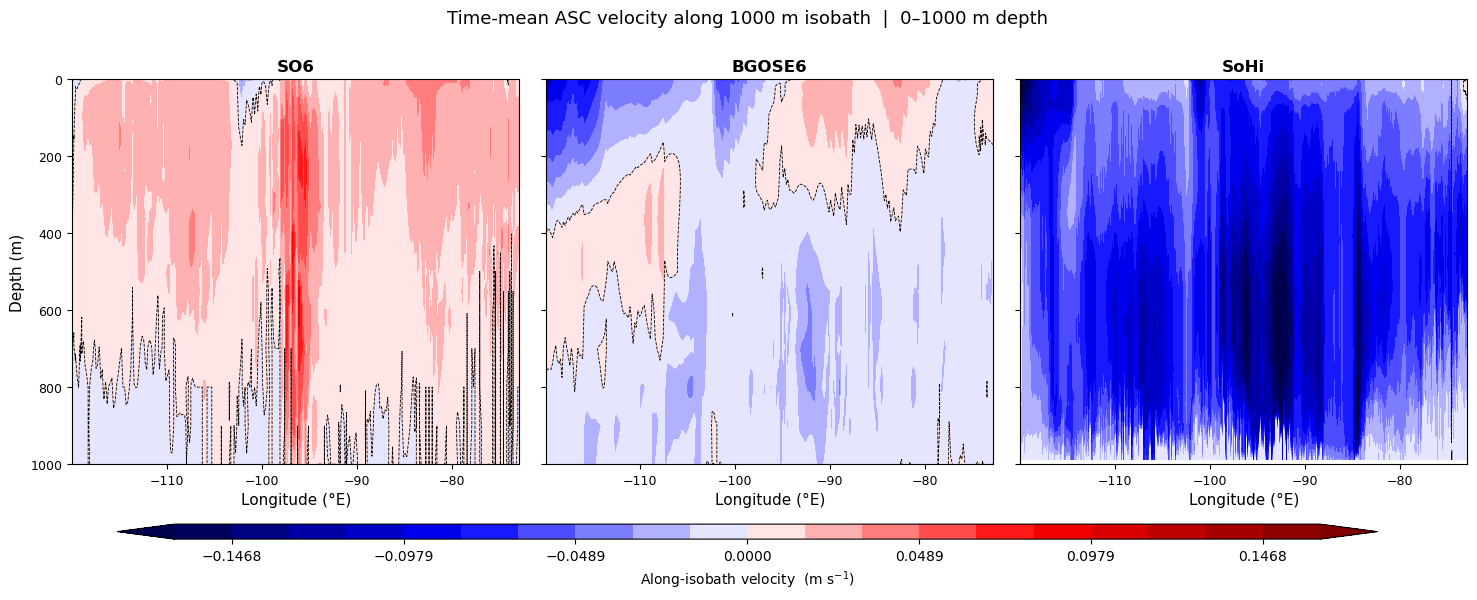

Saved SOSE_ASC_isobath_section.png


In [10]:
# ASC depth-section: contourf of time-mean u_along, depth vs longitude along 1000m isobath
levels = np.linspace(-vmax_sec, vmax_sec, 21)

titles   = ['SO6', 'BGOSE6', 'SoHi']
lons_all = [lon_so6_ase,   lon_bgose_ase,   lon_sohi_ase]
deps_all = [sec_so6_dep,   sec_bgose_dep,   sec_sohi_dep]
Zarr_all = [sec_so6_Z,     sec_bgose_Z,     sec_sohi_Z]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True,
                         gridspec_kw={'wspace': 0.06})

for ax, title, lons, deps, Z in zip(axes, titles, lons_all, deps_all, Zarr_all):
    # deps are negative (0 = surface, -1000 = deep); flip sign for positive y-axis
    cf = ax.contourf(lons, -deps, Z,
                     levels=levels, cmap='seismic', extend='both')
    ax.contour(lons, -deps, Z,
               levels=[0.0], colors='k', linewidths=0.6, linestyles='--')
    ax.set_xlim(lons.min(), lons.max())
    ax.set_ylim(0, 1000)
    ax.invert_yaxis()
    ax.set_xlabel('Longitude (°E)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(labelsize=9)

axes[0].set_ylabel('Depth (m)', fontsize=11)
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

cbar_ax = fig.add_axes([0.15, -0.04, 0.70, 0.03])
cbar = fig.colorbar(cf, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label('Along-isobath velocity  (m s$^{-1}$)', fontsize=10)

fig.suptitle('Time-mean ASC velocity along 1000 m isobath  |  0–1000 m depth',
             y=1.02, fontsize=13)

plt.savefig('SOSE_ASC_isobath_section.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved SOSE_ASC_isobath_section.png')

In [11]:
import pandas as pd

# Monthly climatology of ASC velocity, spatially averaged over ASE s-indices.
# Result shape for each sim: (12, n_depth) with depth clipped to 0–1000 m.

d_mask_so6   = asc_so6['u_along'].depth.values   >= -1000.0
d_mask_bgose = asc_bgose['u_along'].depth.values >= -1000.0
d_mask_sohi  = asc_sohi['u_along'].depth.values  >= -1000.0

# SO6 / BGOSE6 — monthly data, multi-year groupby
clim_so6   = (asc_so6['u_along']
              .isel(depth=d_mask_so6, s=s_so6)
              .mean('s')
              .groupby('time.month').mean()
              .compute())   # (12, n_depth)

clim_bgose = (asc_bgose['u_along']
              .isel(depth=d_mask_bgose, s=s_bgose)
              .mean('s')
              .groupby('time.month').mean()
              .compute())

# SoHi — daily 2007; assign calendar dates then groupby month
n_days = len(asc_sohi['u_along'].date)
sohi_cal = pd.date_range('2007-01-01', periods=n_days, freq='D')
clim_sohi = (asc_sohi['u_along']
             .isel(depth=d_mask_sohi, s=s_sohi)
             .assign_coords(date=('date', sohi_cal))
             .mean('s')
             .groupby('date.month').mean()
             .compute())   # (12, n_depth)

# Shared colour scale
vmax_clim = float(np.nanpercentile(np.abs(np.concatenate([
    clim_so6.values.ravel(),
    clim_bgose.values.ravel(),
    clim_sohi.values.ravel(),
])), 99))

dep_so6_clim  = -clim_so6.depth.values    # positive depths for y-axis
dep_bgose_clim = -clim_bgose.depth.values
dep_sohi_clim  = -clim_sohi.depth.values
months = np.arange(1, 13)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

print(f'Climatology shapes — SO6: {clim_so6.shape}  BGOSE6: {clim_bgose.shape}  SoHi: {clim_sohi.shape}')
print(f'Shared colour scale: ±{vmax_clim:.4f} m/s')

Climatology shapes — SO6: (12, 36)  BGOSE6: (12, 36)  SoHi: (12, 119)
Shared colour scale: ±0.1218 m/s


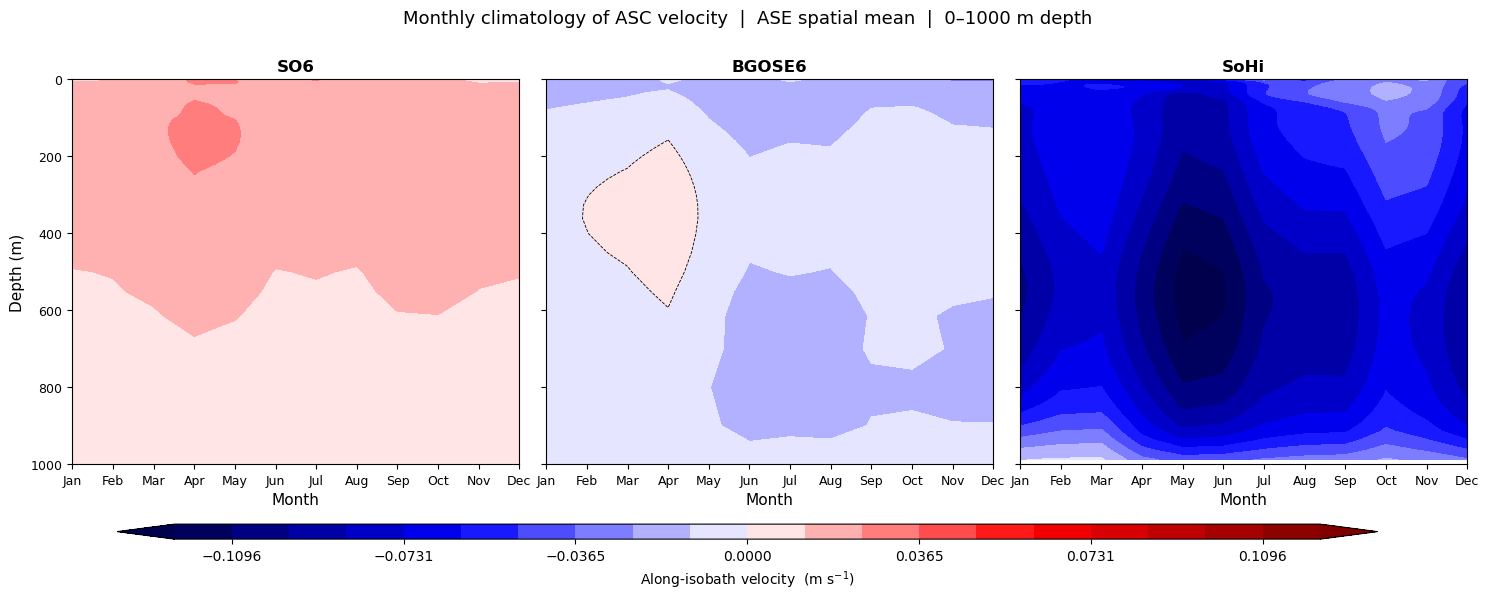

Saved SOSE_ASC_isobath_seasonal.png


In [12]:
levels_clim = np.linspace(-vmax_clim, vmax_clim, 21)

panels_clim = [
    ('SO6',    months, dep_so6_clim,   clim_so6.values.T),    # transpose → (depth, month)
    ('BGOSE6', months, dep_bgose_clim, clim_bgose.values.T),
    ('SoHi',   months, dep_sohi_clim,  clim_sohi.values.T),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True,
                         gridspec_kw={'wspace': 0.06})

for ax, (title, mo, dep, Z) in zip(axes, panels_clim):
    cf = ax.contourf(mo, dep, Z,
                     levels=levels_clim, cmap='seismic', extend='both')
    ax.contour(mo, dep, Z,
               levels=[0.0], colors='k', linewidths=0.6, linestyles='--')
    ax.set_xlim(1, 12)
    ax.set_xticks(months)
    ax.set_xticklabels(month_labels, fontsize=8)
    ax.set_ylim(0, 1000)
    ax.invert_yaxis()
    ax.set_xlabel('Month', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(labelsize=9)

axes[0].set_ylabel('Depth (m)', fontsize=11)
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

cbar_ax = fig.add_axes([0.15, -0.04, 0.70, 0.03])
cbar = fig.colorbar(cf, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label('Along-isobath velocity  (m s$^{-1}$)', fontsize=10)

fig.suptitle('Monthly climatology of ASC velocity  |  ASE spatial mean  |  0–1000 m depth',
             y=1.02, fontsize=13)

plt.savefig('SOSE_ASC_isobath_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved SOSE_ASC_isobath_seasonal.png')

In [13]:
# Summary figure data prep: time-and-space mean ASC velocity per simulation.
# Errorbar = std of annual means (interannual variability); SoHi has no errorbar (1 year).

def _annual_mean_ase(u_zarr, s_idx, time_dim, depth_min=-1000.0):
    """Return array of annual-mean, depth-and-space-averaged u_along (one value per year)."""
    d_mask = u_zarr.depth.values >= depth_min
    da = u_zarr.isel(depth=d_mask, s=s_idx).mean(['s', 'depth'])
    if time_dim == 'time':
        return da.groupby('time.year').mean().compute().values
    else:
        # SoHi: single year of daily data → single mean value
        return da.mean().compute().values[np.newaxis]   # shape (1,)

ann_so6   = _annual_mean_ase(asc_so6['u_along'],   s_so6,   'time')
ann_bgose = _annual_mean_ase(asc_bgose['u_along'], s_bgose, 'time')

# SoHi: assign calendar dates before passing (avoids float32 date issues)
n_days_s = len(asc_sohi['u_along'].date)
sohi_cal_s = pd.date_range('2007-01-01', periods=n_days_s, freq='D')
u_sohi_cal = asc_sohi['u_along'].assign_coords(date=('date', sohi_cal_s))
ann_sohi = _annual_mean_ase(u_sohi_cal, s_sohi, 'date')   # shape (1,) — no groupby needed

mu_so6,    std_so6    = ann_so6.mean(),   ann_so6.std()
mu_bgose,  std_bgose  = ann_bgose.mean(), ann_bgose.std()
mu_sohi                = ann_sohi.mean()

print(f'SO6:    {mu_so6:.4f} ± {std_so6:.4f} m/s  (n={len(ann_so6)} years)')
print(f'BGOSE6: {mu_bgose:.4f} ± {std_bgose:.4f} m/s  (n={len(ann_bgose)} years)')
print(f'SoHi:   {mu_sohi:.4f} m/s  (n=1 year, no errorbar)')

SO6:    0.0178 ± 0.0053 m/s  (n=9 years)
BGOSE6: -0.0101 ± 0.0051 m/s  (n=9 years)
SoHi:   -0.0692 m/s  (n=1 year, no errorbar)


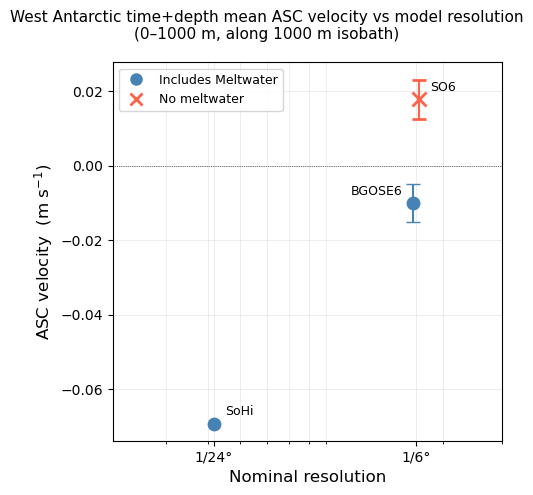

Saved SOSE_ASC_summary.png


In [18]:
import matplotlib.lines as mlines

# Summary figure: resolution vs ASC velocity
# SO6: no meltwater (×);  BGOSE6, SoHi: meltwater (○)
# Errorbars = interannual std; SoHi has no errorbar (single year)

res_sixth  = 1/6
res_twfour = 1/24
jitter = 0.003   # x-offset so SO6 and BGOSE6 don't overlap

fig, ax = plt.subplots(figsize=(5, 5))

# BGOSE6 — meltwater, circle
ax.errorbar(res_sixth - jitter, mu_bgose, yerr=std_bgose,
            fmt='o', color='steelblue', markersize=9, capsize=5,
            linewidth=1.5)
ax.annotate('BGOSE6', xy=(res_sixth - jitter, mu_bgose),
            xytext=(-8, 6), textcoords='offset points',
            fontsize=9, ha='right')

# SO6 — no meltwater, ×
ax.errorbar(res_sixth + jitter, mu_so6, yerr=std_so6,
            fmt='x', color='tomato', markersize=10, capsize=5,
            linewidth=1.5, markeredgewidth=2)
ax.annotate('SO6', xy=(res_sixth + jitter, mu_so6),
            xytext=(8, 6), textcoords='offset points',
            fontsize=9, ha='left')

# SoHi — meltwater, circle (no errorbar)
ax.scatter(res_twfour, mu_sohi,
           marker='o', color='steelblue', s=80, zorder=5)
ax.annotate('SoHi', xy=(res_twfour, mu_sohi),
            xytext=(8, 6), textcoords='offset points',
            fontsize=9, ha='left')

ax.axhline(0, color='k', linewidth=0.5, linestyle=':')

# Legend: symbol type only
legend_handles = [
    mlines.Line2D([], [], color='steelblue', marker='o', linestyle='None',
                  markersize=8, label='Includes Meltwater'),
    mlines.Line2D([], [], color='tomato', marker='x', linestyle='None',
                  markersize=9, markeredgewidth=2, label='No meltwater'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='best')

ax.set_xscale('log')
ax.set_xticks([res_twfour, res_sixth])
ax.set_xticklabels(['1/24°', '1/6°'], fontsize=11)
ax.set_xlim(res_twfour * 0.5, res_sixth * 1.8)
ax.set_xlabel('Nominal resolution', fontsize=12)
ax.set_ylabel('ASC velocity  (m s$^{-1}$)', fontsize=12)
ax.tick_params(labelsize=10)
ax.grid(True, which='both', linewidth=0.4, alpha=0.4)

fig.suptitle('West Antarctic time+depth mean ASC velocity vs model resolution\n(0–1000 m, along 1000 m isobath)',
             fontsize=11)

plt.tight_layout()
plt.savefig('SOSE_ASC_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved SOSE_ASC_summary.png')

/home/zkaufman/miniconda3/envs/base_env/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 486.74 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


115W transect shapes — SO6: (37, 18)   BGOSE6: (37, 16)   SoHi: (126, 74)
SO6  115W grid lon: -115.08°  (115.08°W)
SoHi 115W grid lon: -115.02°  (115.02°W)
Shared colour scale: ±0.1065 m/s


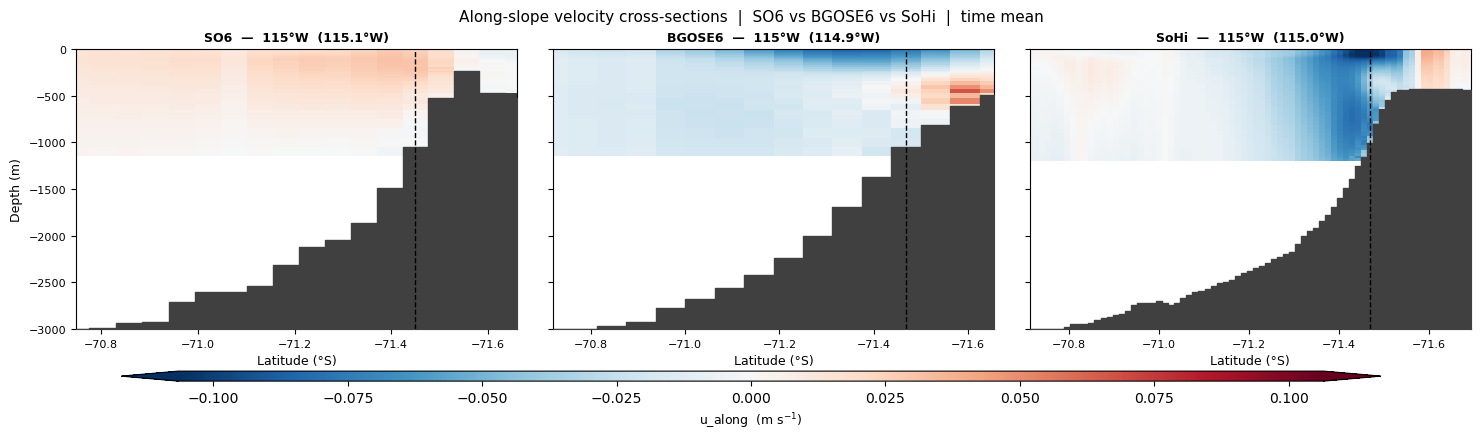

Saved SOSE_transect_sections.png


In [15]:
lon_115W = -115.0   # 115°W in -180-180 convention (was 245.0°E)
lat_tr_115 = slice(-71.7, -70.7)

u_tr_so6_115   = u_3d_so6.sel(lon=lon_115W,  method='nearest').sel(lat=lat_tr_115).mean('time').compute()
u_tr_bgose_115 = u_3d_bgose.sel(lon=lon_115W, method='nearest').sel(lat=lat_tr_115).mean('time').compute()
u_tr_sohi_115  = u_3d_sohi.sel(lon=lon_115W,  method='nearest').sel(lat=lat_tr_115).mean('date').compute()

btr_so6_115   = bathym_so6.sel(lon=lon_115W,  method='nearest').sel(lat=lat_tr_115).values
btr_bgose_115 = bathym_bgose.sel(lon=lon_115W, method='nearest').sel(lat=lat_tr_115).values
btr_sohi_115  = bathym_sohi.sel(lon=lon_115W,  method='nearest').sel(lat=lat_tr_115).values

print('115W transect shapes — SO6:', u_tr_so6_115.shape,
      '  BGOSE6:', u_tr_bgose_115.shape,
      '  SoHi:', u_tr_sohi_115.shape)

lon_so6_115   = float(u_3d_so6.lon.sel(lon=lon_115W,  method='nearest'))
lon_bgose_115 = float(u_3d_bgose.lon.sel(lon=lon_115W, method='nearest'))
lon_sohi_115  = float(u_3d_sohi.lon.sel(lon=lon_115W,  method='nearest'))
print(f'SO6  115W grid lon: {lon_so6_115:.2f}°  ({abs(lon_so6_115):.2f}°W)')
print(f'SoHi 115W grid lon: {lon_sohi_115:.2f}°  ({abs(lon_sohi_115):.2f}°W)')

vmax_tr = max(
    float(np.nanpercentile(np.abs(np.where(u_tr_so6_115.values   == 0, np.nan, u_tr_so6_115.values)),   99)),
    float(np.nanpercentile(np.abs(np.where(u_tr_bgose_115.values == 0, np.nan, u_tr_bgose_115.values)), 99)),
    float(np.nanpercentile(np.abs(u_tr_sohi_115.values), 99)),
)
print(f'Shared colour scale: ±{vmax_tr:.4f} m/s')

cmap_sec = plt.get_cmap('RdBu_r').copy()
cmap_sec.set_bad(color='0.25')

fig, axes = plt.subplots(1, 3, figsize=(18, 4),
                          sharey=True,
                          gridspec_kw={'wspace': 0.08})

panels = [
    (axes[0], u_tr_so6_115,   btr_so6_115,   'SO6',    lon_so6_115,   '115°W'),
    (axes[1], u_tr_bgose_115, btr_bgose_115, 'BGOSE6', lon_bgose_115, '115°W'),
    (axes[2], u_tr_sohi_115,  btr_sohi_115,  'SoHi',   lon_sohi_115,  '115°W'),
]

for ax, u_da, bathy_tr, sim, grid_lon, tr_label in panels:
    lat = u_da.lat.values
    dep = u_da.depth.values

    u_masked = np.ma.masked_where(u_da.values == 0, u_da.values)

    pcm = ax.pcolormesh(lat, dep, u_masked,
                        cmap=cmap_sec,
                        vmin=-vmax_tr, vmax=vmax_tr,
                        shading='nearest')

    seafloor_depth = -bathy_tr
    ax.fill_between(lat, seafloor_depth, -3000,
                    color='0.25', step='mid', zorder=3)

    lat_1000 = lat[np.argmin(np.abs(bathy_tr - 1000.0))]
    ax.axvline(lat_1000, color='k', linestyle='--', linewidth=1.0, zorder=4)

    ax.set_ylim(-3000, 0)
    ax.set_xlim(lat[-1], lat[0])
    ax.set_xlabel('Latitude (°S)', fontsize=9)
    ax.set_title(f'{sim}  —  {tr_label}  ({abs(grid_lon):.1f}°W)', fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('Depth (m)', fontsize=9)

fig.subplots_adjust(bottom=0.18)
cax_tr = fig.add_axes([0.15, 0.05, 0.70, 0.025])
cb = fig.colorbar(pcm, cax=cax_tr, orientation='horizontal', extend='both')
cb.set_label('u_along  (m s$^{-1}$)', fontsize=9)

fig.suptitle('Along-slope velocity cross-sections  |  SO6 vs BGOSE6 vs SoHi  |  time mean',
             fontsize=11)

plt.savefig('SOSE_transect_sections.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved SOSE_transect_sections.png')

In [ ]:
# proj = ccrs.SouthPolarStereo(central_longitude=265)
# pc   = ccrs.PlateCarree()
# 
# fig = plt.figure(figsize=(19, 13))
# gs  = GridSpec(4, 3, figure=fig,
#                height_ratios=[5, 0.25, 5, 0.25],
#                hspace=0.55, wspace=0.08)
# 
# axes = np.array([
#     [fig.add_subplot(gs[0, 0], projection=proj), fig.add_subplot(gs[0, 1], projection=proj), fig.add_subplot(gs[0, 2], projection=proj)],
#     [fig.add_subplot(gs[2, 0], projection=proj), fig.add_subplot(gs[2, 1], projection=proj), fig.add_subplot(gs[2, 2], projection=proj)],
# ])
# cax0 = fig.add_subplot(gs[1, :])
# cax1 = fig.add_subplot(gs[3, :])
# 
# def setup_ax(ax):
#     ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=pc)
#     ax.add_feature(cfeature.LAND, facecolor='black', zorder=3)
#     ax.coastlines(color='black', linewidth=0.6, zorder=4)
#     gl = ax.gridlines(crs=pc, draw_labels=True,
#                       linewidth=0.5, linestyle=':', color='gray', zorder=2)
#     gl.xlocator      = mticker.FixedLocator([-120, -105, -90, -75])
#     gl.ylocator      = mticker.FixedLocator([-76, -72, -68, -64, -60])
#     gl.top_labels    = False
#     gl.right_labels  = False
#     gl.left_labels   = True
#     gl.bottom_labels = True
#     gl.xformatter    = LONGITUDE_FORMATTER
#     gl.yformatter    = LATITUDE_FORMATTER
#     gl.xlabel_style  = {'size': 7}
#     gl.ylabel_style  = {'size': 7}
# 
# iso_levels   = [500, 1000, 2000, 3000]
# time_domains = {'SO6': '2013–2021', 'BGOSE6': '2013–2021', 'SoHi': '2007'}
# 
# # Row 0: u_along at ~100m
# vmax1 = max(float(np.nanpercentile(np.abs(u_100m_so6_mean.values),   99)),
#             float(np.nanpercentile(np.abs(u_100m_bgose_mean.values), 99)),
#             float(np.nanpercentile(np.abs(u_100m_sohi_mean.values),  99)))
# 
# for ax, u_da, bm, sim, dlbl in zip(
#         axes[0],
#         [u_100m_so6_mean, u_100m_bgose_mean, u_100m_sohi_mean],
#         [bathy_so6_m,     bathy_bgose_m,     bathy_sohi_m],
#         ['SO6', 'BGOSE6', 'SoHi'],
#         [f'{depth_100_so6:.0f} m', f'{depth_100_bgose:.0f} m', f'{depth_100_sohi:.0f} m']):
#     setup_ax(ax)
#     pcm1 = u_da.plot.pcolormesh(
#         ax=ax, transform=pc, cmap='RdBu_r',
#         vmin=-vmax1, vmax=vmax1,
#         add_colorbar=False, add_labels=False, shading='auto', zorder=1)
#     lon2d, lat2d = np.meshgrid(bm.lon, bm.lat)
#     ax.contour(lon2d, lat2d, bm.values,
#                levels=iso_levels, colors='k',
#                linewidths=0.4, alpha=0.5, transform=pc, zorder=2)
#     ax.set_title(f'{sim}  ({dlbl})', fontsize=9, fontweight='bold')
# 
# cb0 = fig.colorbar(pcm1, cax=cax0, orientation='horizontal', extend='both')
# cb0.set_label('u_along at ~100 m  (m/s)', fontsize=9)
# 
# # Row 1: u_along at ~500m
# vmax2 = max(float(np.nanpercentile(np.abs(u_500m_so6_mean.values),   99)),
#             float(np.nanpercentile(np.abs(u_500m_bgose_mean.values), 99)),
#             float(np.nanpercentile(np.abs(u_500m_sohi_mean.values),  99)))
# 
# for ax, u_da, bm, sim, dlbl in zip(
#         axes[1],
#         [u_500m_so6_mean, u_500m_bgose_mean, u_500m_sohi_mean],
#         [bathy_so6_m,     bathy_bgose_m,     bathy_sohi_m],
#         ['SO6', 'BGOSE6', 'SoHi'],
#         [f'{depth_500_so6:.0f} m', f'{depth_500_bgose:.0f} m', f'{depth_500_sohi:.0f} m']):
#     setup_ax(ax)
#     pcm2 = u_da.plot.pcolormesh(
#         ax=ax, transform=pc, cmap='RdBu_r',
#         vmin=-vmax2, vmax=vmax2,
#         add_colorbar=False, add_labels=False, shading='auto', zorder=1)
#     lon2d, lat2d = np.meshgrid(bm.lon, bm.lat)
#     ax.contour(lon2d, lat2d, bm.values,
#                levels=iso_levels, colors='k',
#                linewidths=0.4, alpha=0.5, transform=pc, zorder=2)
#     ax.set_title(f'{sim}  ({dlbl})', fontsize=9, fontweight='bold')
# 
# cb1 = fig.colorbar(pcm2, cax=cax1, orientation='horizontal', extend='both')
# cb1.set_label('u_along at ~500 m  (m/s)', fontsize=9)
# 
# # Overlay 1000m isobath (yellow) on all 6 panels
# for ax, iso_x, iso_y in zip(axes.flatten(),
#                              [iso_x_so6, iso_x_bgose, iso_x_sohi] * 2,
#                              [iso_y_so6, iso_y_bgose, iso_y_sohi] * 2):
#     ax.plot(iso_x, iso_y, color='yellow', linewidth=1.5, transform=pc, zorder=5)
# 
# for ax, label in zip(axes[:, 0], ['u_along\n~100 m', 'u_along\n~500 m']):
#     ax.text(-0.10, 0.5, label, transform=ax.transAxes,
#             va='center', ha='right', fontsize=8, rotation=90)
# 
# fig.suptitle('Amundsen-Bellingshausen Sea  |  SO6 vs BGOSE6 vs SoHi  |  time mean',
#              fontsize=11, y=1.005)
# 
# plt.savefig('SOSE_compare_maps_ASE.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('Saved SOSE_compare_maps_ASE.png')

In [18]:
# import pandas as pd
# 
# # 1000m isobath latitude along 115W for each sim — matches dashed lines in transect figure
# lat_1000_so6   = float(u_tr_so6_115.lat.values[np.argmin(np.abs(btr_so6_115   - 1000.0))])
# lat_1000_bgose = float(u_tr_bgose_115.lat.values[np.argmin(np.abs(btr_bgose_115 - 1000.0))])
# lat_1000_sohi  = float(u_tr_sohi_115.lat.values[np.argmin(np.abs(btr_sohi_115  - 1000.0))])
# print(f'1000m isobath lat — SO6: {lat_1000_so6:.3f}°  BGOSE6: {lat_1000_bgose:.3f}°  SoHi: {lat_1000_sohi:.3f}°')
# 
# # Extract single-point time series at 1000m isobath lat, 115W, for both depth levels
# ts_so6_100m   = u_100m_so6.sel(lon=lon_115W,  method='nearest').sel(lat=lat_1000_so6,   method='nearest').compute()
# ts_so6_500m   = u_500m_so6.sel(lon=lon_115W,  method='nearest').sel(lat=lat_1000_so6,   method='nearest').compute()
# ts_bgose_100m = u_100m_bgose.sel(lon=lon_115W, method='nearest').sel(lat=lat_1000_bgose, method='nearest').compute()
# ts_bgose_500m = u_500m_bgose.sel(lon=lon_115W, method='nearest').sel(lat=lat_1000_bgose, method='nearest').compute()
# ts_sohi_100m  = u_100m_sohi.sel(lon=lon_115W,  method='nearest').sel(lat=lat_1000_sohi,  method='nearest').compute()
# ts_sohi_500m  = u_500m_sohi.sel(lon=lon_115W,  method='nearest').sel(lat=lat_1000_sohi,  method='nearest').compute()
# 
# # SoHi date coordinate is float32 model time — map to calendar dates for plotting
# sohi_dates = pd.date_range('2007-01-01', periods=len(ts_sohi_100m.date), freq='D')
# 
# print(f'SO6   n={len(ts_so6_100m.time)}  ({str(ts_so6_100m.time.values[0])[:10]} – {str(ts_so6_100m.time.values[-1])[:10]})')
# print(f'BGOSE n={len(ts_bgose_100m.time)}  ({str(ts_bgose_100m.time.values[0])[:10]} – {str(ts_bgose_100m.time.values[-1])[:10]})')
# print(f'SoHi  n={len(ts_sohi_100m.date)}  ({str(sohi_dates[0].date())} – {str(sohi_dates[-1].date())})')

1000m isobath lat — SO6: -71.450°  BGOSE6: -71.469°  SoHi: -71.470°


/home/zkaufman/miniconda3/envs/base_env/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 220.33 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


SO6   n=108  (2013-01-01 – 2021-12-01)
BGOSE n=108  (2013-01-01 – 2021-12-01)
SoHi  n=365  (2007-01-01 – 2007-12-31)


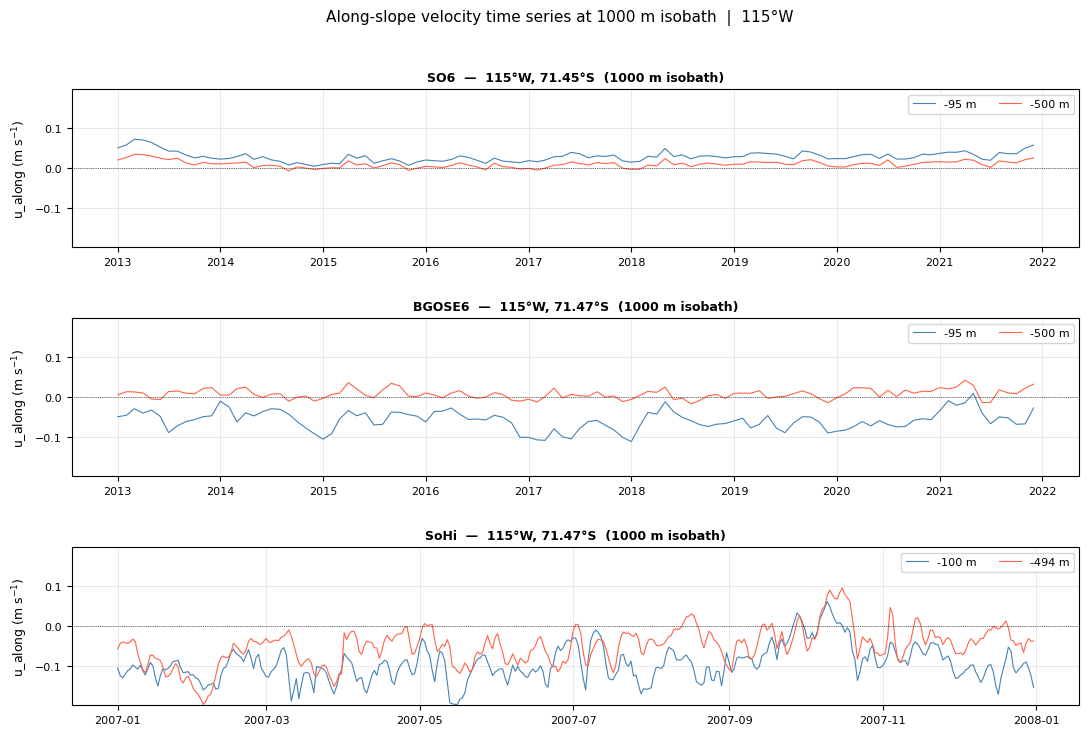

Saved SOSE_timeseries_ASE.png


In [19]:
# # Shared y-axis limits from 99th percentile across all six time series
# all_vals = np.concatenate([
#     ts_so6_100m.values,   ts_so6_500m.values,
#     ts_bgose_100m.values, ts_bgose_500m.values,
#     ts_sohi_100m.values,  ts_sohi_500m.values,
# ])
# ylim = float(np.nanpercentile(np.abs(all_vals), 99)) * 1.15
# 
# fig, axes = plt.subplots(3, 1, figsize=(13, 8),
#                           gridspec_kw={'hspace': 0.45})
# 
# panels = [
#     (axes[0], ts_so6_100m.time.values,   ts_so6_100m.values,   ts_so6_500m.values,
#      'SO6',    f'{depth_100_so6:.0f} m',   f'{depth_500_so6:.0f} m'),
#     (axes[1], ts_bgose_100m.time.values, ts_bgose_100m.values, ts_bgose_500m.values,
#      'BGOSE6', f'{depth_100_bgose:.0f} m', f'{depth_500_bgose:.0f} m'),
#     (axes[2], sohi_dates,                ts_sohi_100m.values,  ts_sohi_500m.values,
#      'SoHi',   f'{depth_100_sohi:.0f} m',  f'{depth_500_sohi:.0f} m'),
# ]
# 
# for ax, t, v100, v500, sim, lbl100, lbl500 in panels:
#     ax.plot(t, v100, color='steelblue', linewidth=0.8, label=lbl100)
#     ax.plot(t, v500, color='tomato',    linewidth=0.8, label=lbl500)
#     ax.axhline(0, color='k', linewidth=0.5, linestyle=':')
#     ax.set_ylim(-ylim, ylim)
#     ax.set_ylabel('u_along (m s$^{-1}$)', fontsize=9)
#     ax.set_title(f'{sim}  —  115°W, {abs(lat_1000_so6 if sim == "SO6" else lat_1000_bgose if sim == "BGOSE6" else lat_1000_sohi):.2f}°S  (1000 m isobath)',
#                  fontsize=9, fontweight='bold')
#     ax.legend(fontsize=8, loc='upper right', ncol=2)
#     ax.tick_params(labelsize=8)
#     ax.grid(True, linewidth=0.4, alpha=0.5)
# 
# fig.suptitle('Along-slope velocity time series at 1000 m isobath  |  115°W',
#              fontsize=11)
# 
# plt.savefig('SOSE_timeseries_ASE.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('Saved SOSE_timeseries_ASE.png')